In [1]:
import os
import time
import json
import pickle
import pandas as pd
import numpy as np

from datetime import datetime
from tqdm import tqdm
from dotenv import load_dotenv
from pathlib import Path

In [2]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.metrics.pairwise import cosine_similarity

from huggingface_hub import login
import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from transformers import AutoConfig, AutoTokenizer, AutoModelForSequenceClassification
from transformers.optimization import get_linear_schedule_with_warmup
from vllm import LLM, SamplingParams
import optuna

import mlflow
from databricks.sdk import WorkspaceClient

/opt/conda/lib/python3.11/site-packages/torch/utils/_pytree.py:185: FutureWarning: optree is installed but the version is too old to support PyTorch Dynamo in C++ pytree. C++ pytree support is disabled. Please consider upgrading optree using `python3 -m pip install --upgrade 'optree>=0.13.0'`.
  warnings.warn(
2026-01-02 03:41:16.041558: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-01-02 03:41:16.051376: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-01-02 03:41:16.063025: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one h

INFO 01-02 03:41:17 [__init__.py:239] Automatically detected platform cuda.


In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

Define path variables

In [4]:
model_id = "answerdotai/ModernBERT-large"
model_name = "ModernBERT-large"
classification_type = "classification_head"

developer_initials = "JP"

In [5]:
current_dir = Path.cwd()
env_path = current_dir.parent.parent / "conf" / "local" / ".env"
results_path = current_dir.parent.parent / "results" / "transformer"

train_data_full_cleaned_path = current_dir.parent.parent / "data" /  "01_processed" / "pan20-authorship-verification-training-large-cleaned.jsonl"
validation_data_full_cleaned_path = current_dir.parent.parent / "data" /  "01_processed" / "pan20-authorship-verification-validation-large-cleaned.jsonl"
test_data_full_cleaned_path = current_dir.parent.parent / "data" /  "01_processed" / "pan21-authorship-verification-test-cleaned.jsonl"

run_name=f"{developer_initials}_{model_name}_{results_path}_{classification_type}"

Load environment variables
Get access to HuggingFace

In [6]:
load_dotenv(env_path)
huggingface_acess_token = os.getenv("huggingface_jp")

Connect to databricks for logging results

In [7]:
w = WorkspaceClient()   
print("Connected to:", w.config.host)

mlflow.set_tracking_uri("databricks")
mlflow.autolog()

2026/01/02 03:41:19 INFO mlflow.tracking.fluent: Autologging successfully enabled for keras.
2026/01/02 03:41:20 INFO mlflow.tracking.fluent: Autologging successfully enabled for openai.


Connected to: https://dbc-1ea3ad0e-f504.cloud.databricks.com


2026/01/02 03:41:20 WARNING mlflow.utils.autologging_utils: MLflow sklearn autologging is known to be compatible with 1.4.0 <= scikit-learn, but the installed version is 1.3.2. If you encounter errors during autologging, try upgrading / downgrading scikit-learn to a compatible version, or try upgrading MLflow.
2026/01/02 03:41:20 INFO mlflow.tracking.fluent: Autologging successfully enabled for sklearn.
2026/01/02 03:41:20 WARNING mlflow.utils.autologging_utils: MLflow statsmodels autologging is known to be compatible with 0.14.1 <= statsmodels, but the installed version is 0.14.0. If you encounter errors during autologging, try upgrading / downgrading statsmodels to a compatible version, or try upgrading MLflow.
2026/01/02 03:41:20 INFO mlflow.tracking.fluent: Autologging successfully enabled for statsmodels.
2026/01/02 03:41:20 WARNING mlflow.tracking.fluent: Exception raised while enabling autologging for tensorflow: cannot import name '_initialize_variables' from 'keras.src.backend

What are GPU are the experiments run on

In [8]:
!nvidia-smi

Fri Jan  2 03:41:21 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.105.08             Driver Version: 580.105.08     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA H100 NVL                Off |   00000000:82:00.0 Off |                    0 |
| N/A   64C    P0             75W /  400W |       0MiB /  95830MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [9]:
running_on_gpu = torch.cuda.is_available()
device = torch.device("cuda" if running_on_gpu else "cpu")

In [10]:
if running_on_gpu:
    gpu_name = torch.cuda.get_device_name(0)
    gpu_props = torch.cuda.get_device_properties(0)
    gpu_vram_gb = round(gpu_props.total_memory / (1024**3), 2)
else:
    gpu_name = "CPU"
    gpu_props = "N/A"
    gpu_vram_gb = 0

Empty the GPU from previous experiments

In [11]:
import gc
import torch
torch.cuda.empty_cache()
gc.collect()

122

In [12]:
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

Definition of the training constants

In [13]:
optimizer_learning_rate_range = (1e-6, 5e-5)
epochs_range = (1, 3)
batch_size = [2, 4, 8]

weight_decay = (0.0, 0.1)
warmup_ratio = [0.0, 0.5, 0.1]
classifier_dropout = (0.0, 0.3)

classification_thresholds = [x/1000 for x in range(100, 999)]

Training dataset size for tuning

In [14]:
train_tuning_size = 19_999

# Load training data

In [15]:
train_data_file_size = os.path.getsize(train_data_full_cleaned_path)
train_data = []

with open(train_data_full_cleaned_path, 'r') as f:
    with tqdm(total=train_data_file_size, desc="Loading data", unit='B', unit_scale=True) as pbar:
        for line in f:
            train_data.append(json.loads(line))
            pbar.update(len(line.encode('utf-8')))

print(f"\nSuccessfully loaded {len(train_data)} items.")

Loading data: 100%|██████████| 11.3G/11.3G [02:13<00:00, 84.5MB/s]


Successfully loaded 273301 items.


In [16]:
train_data_df = pd.DataFrame(train_data)

Prepare dataset for cosine embedding loss

In [17]:
train_data_df.head(10)

,id,pair,same
0,e05b9c0b-88a1-5608-b7e8-ab1fc6b78dc1,"[Well, ever since you and Kurt broke up youve ...",False
1,12f73a20-cdf3-58df-b5bb-9392eec9b486,"[The thing is, Ryouga has no reason to run aft...",False
2,d82c6764-451b-544c-8711-c139e9349c56,"[Ehhhh nah, its silly' Its my job to listen to...",True
3,876b8380-9260-5427-93e8-dc31155c3edd,"[Glaring at the arrogant spark, Always asks va...",False
4,357e8471-35b9-50b4-9ac0-286ac0e8b101,[Runa limped across the small space to an open...,False
5,6b39fe22-409f-5329-9fe1-ddf4a70bedd1,"[And thats retired Commander, if you please St...",False
6,76ed2017-0c9f-580f-83b1-5a041a8169ec,[Meet you downstairs in twenty minutes I say w...,True
7,fd8deb2e-06de-5c92-9a4c-927891c53657,"[Since Ive seen so many others do so, Im going...",False
8,3ce5e811-a57c-5fbf-9f9a-2ee636e50be6,[party Eishi exclaimed Omi shook his head and ...,False
9,25a17cd2-6b01-5fba-99ef-e631e56e181d,[After a few moments she found that Red was ri...,False


#### Create a subset of training data for finetuning

In [18]:
train_tuning_data_df = train_data_df.sample(n=train_tuning_size, random_state=42)
train_tuning_data_df = train_tuning_data_df.reset_index(drop=True)
train_tuning_data_df.head()

,id,pair,same
0,1c4a05b6-dabb-5a9d-9e6a-7709b07d8dff,[comes home at about onethirty that night Case...,True
1,aff2cdfb-625d-5fa7-acb8-a0ff9876b34f,"[He rubbed his tired, gritty eyes The clock on...",False
2,15fc44d2-e1c9-574b-9fa3-fdb29f20cc68,"[Mikado grinned and explained, no longer using...",False
3,e77681c2-8d90-5cac-8ab0-07d7c9277670,[Thanks he smiled Now to write Characters and ...,False
4,8c38b587-f54c-5e52-94cb-abb48ce14c5a,"[soldierscare that ended earlier, and all were...",True


#### Load validation data

In [19]:
val_data_file_size = os.path.getsize(validation_data_full_cleaned_path)
val_data = []

with open(validation_data_full_cleaned_path, 'r') as f:
    with tqdm(total=val_data_file_size, desc="Loading data", unit='B', unit_scale=True) as pbar:
        for line in f:
            val_data.append(json.loads(line))
            pbar.update(len(line.encode('utf-8')))

print(f"\nSuccessfully loaded {len(val_data)} items.")

Loading data: 100%|██████████| 103M/103M [00:01<00:00, 94.2MB/s] 


Successfully loaded 2500 items.


In [20]:
val_data_df = pd.DataFrame(val_data)

In [21]:
print(len(val_data_df))

2500


#### Load testing data

In [22]:
test_data_file_size = os.path.getsize(test_data_full_cleaned_path)
test_data = []

with open(test_data_full_cleaned_path, 'r') as f:
    with tqdm(total=test_data_file_size, desc="Loading data", unit='B', unit_scale=True) as pbar:
        for line in f:
            test_data.append(json.loads(line))
            pbar.update(len(line.encode('utf-8')))

print(f"\nSuccessfully loaded {len(test_data)} items.")

Loading data: 100%|██████████| 826M/826M [00:08<00:00, 92.2MB/s] 


Successfully loaded 19999 items.


In [23]:
test_data_df = pd.DataFrame(test_data)

# Set up model

Log in to huggingface

In [24]:
login(huggingface_acess_token)

Load the pre-trained model

In [25]:
tokenizer = AutoTokenizer.from_pretrained(model_id)
config = AutoConfig.from_pretrained(model_id)

# Set up training functions

Helper class for pytorch

In [26]:
class PairDataset(Dataset):
    def __init__(self, df):
        self.df = df

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.loc[idx]
        text1 = row["pair"][0]
        text2 = row["pair"][1]
        label = int(row["same"])
        return text1, text2, label

In [27]:
def evaluate_f1_pruning(model, val_data_df):
    model.eval()
    
    predictions = [] 
    labels = []
    
    with torch.no_grad():
        for i in val_data_df.index:
            text1 = val_data_df.loc[i, "pair"][0]
            text2 = val_data_df.loc[i, "pair"][1]
            
            label = int(val_data_df.loc[i, "same"])
            
            enc = tokenizer(
                text1,
                text2,
                return_tensors="pt",
                padding=True,
                truncation=True,
                max_length=4096
            ).to(device)
            
            logits = model(**enc).logits
            prediction = torch.argmax(logits, dim=-1).item()
            
            predictions.append(prediction)
            labels.append(label)
            
    calculate_f1 = f1_score(labels, predictions, average="weighted")
    model.train()
    
    return calculate_f1

Model training function

In [28]:
def train_classifier(model, df, optimizer, epochs, batch_size, warmup_ratio, val_data_df, trial=None):
    ds = PairDataset(df)
    dataloader = DataLoader(ds, shuffle=True, batch_size=batch_size)

    total_steps = len(dataloader) * epochs
    warmup_steps = int(total_steps * warmup_ratio)

    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=warmup_steps,
        num_training_steps=total_steps
    )
    
    model.train()
    if trial is not None:
        print(f"Starting optuna trial #{trial.number + 1} 🐻")

    best_f1 = -1

    for epoch in range(epochs):
        total_loss = 0

        for text1, text2, labels in tqdm(dataloader, desc=f"Epoch {epoch+1}/{epochs}"):

            labels = labels.to(device)

            enc = tokenizer(
                list(text1),
                list(text2),
                return_tensors="pt",
                padding=True,
                truncation=True,
                max_length=4096
            ).to(device)

            outputs = model(**enc, labels=labels)
            loss = outputs.loss
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            scheduler.step()

            total_loss += loss.item()
            avg_loss = total_loss / len(dataloader)
        
        if val_data_df is not None:
            pruning_f1 = evaluate_f1_pruning(model, val_data_df)

            if trial is not None:
                trial.report(pruning_f1, epoch)
                if trial.should_prune():
                    print(f"Trial {trial.number + 1} successfully pruned.")
                    raise optuna.TrialPruned()

            best_f1 = max(best_f1, pruning_f1)
            
        if trial is not None:
            print(f"Optuna trial #{trial.number + 1} Epoch {epoch+1}/{epochs} complete | Loss: {avg_loss:.4f}")
        else:
            print(f"Epoch {epoch+1}/{epochs} complete | Loss: {avg_loss:.4f}")

    return model, best_f1

# Set up evaluation functions

Evaluate model function

In [29]:
def compute_classifier_scores(test_data_df, model):
    start_time = time.time()
    verification_results = []
    model.eval()

    with torch.no_grad():
        for i in tqdm(test_data_df.index, desc="Testing model"):
            
            resulting_df_row = {}
            resulting_df_row['id']  = test_data_df.loc[i, 'id']
            resulting_df_row['actual_result'] = test_data_df.loc[i, 'same']
            
            text1 = test_data_df.loc[i, 'pair'][0]
            text2 = test_data_df.loc[i, 'pair'][1]

            enc = tokenizer(
                text1,
                text2,
                return_tensors="pt",
                truncation=True,
                padding=True,
                max_length=4096
            ).to(device)

            logits = model(**enc).logits
            probs = F.softmax(logits, dim=-1)
            prob_same = probs[0, 1].item()

            resulting_df_row["propability_same_author"] = prob_same
            verification_results.append(resulting_df_row)

    result_df = pd.DataFrame(verification_results)
    print("--- Execution Time: %s seconds ---" % round(time.time() - start_time, 2))

    return result_df

Evaluation function

In [30]:
def evaluate_results(y_true, y_pred, average='binary'):
    accuracy = round(accuracy_score(y_true, y_pred)*100, 2)
    precision = round(precision_score(y_true, y_pred, average=average, zero_division=0)*100, 2)
    recall = round(recall_score(y_true, y_pred, average=average)*100, 2)
    f1 = round(f1_score(y_true, y_pred, average=average)*100, 2)
    return accuracy, precision, recall, f1

Optimal threshold search

In [31]:
def evaluate_classification_thresholds(result_df, classification_thresholds):
    results = []
    y_embeddings = result_df['propability_same_author']
    y_true = result_df['actual_result']
    for threshold in classification_thresholds:
        y_pred = (result_df["propability_same_author"] >= threshold).astype(int)
        accuracy, precision, recall, f1 = evaluate_results(y_true, y_pred)
        results.append({
            "propability_same_author": threshold,
            "accuracy" : accuracy,
            "precision" : precision,
            "recall" : recall,
            "f1" : f1
        })
    return pd.DataFrame(results)

Create histogram of F1 score for different thresholds

In [32]:
def plot_f1_vs_threshold(results_df):
    plt.figure(figsize=(9, 5))
    plt.plot(results_df["propability_same_author"], results_df["f1"], linewidth=2)
    plt.xlabel("Propability the text belongs to the same author")
    plt.ylabel("F1 Score")
    plt.title("F1 Score vs Classification Threshold")
    plt.grid(True)
    plt.tight_layout()
    return plt.gcf()

Create the confusion matrix

In [33]:
def create_confusion_matrix(y_true, y_pred, labels=[False, True]):
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    
    cm_fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm, annot=True, 
                fmt='d', 
                cmap='Blues',
                xticklabels=labels, 
                yticklabels=labels, 
                ax=ax,
                cbar=False)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(f'Confusion Matrix: {model_id}')
    return cm_fig

# Hyperparameter optimization

Objective function - to train and evaluate all combinations of the model and log the results

In [34]:
def objective(trial):
    lr = trial.suggest_float("lr", optimizer_learning_rate_range[0], optimizer_learning_rate_range[1], log=True)
    epochs = trial.suggest_int("epochs", epochs_range[0], epochs_range[1])
    batch_s = trial.suggest_categorical("batch_size", batch_size)
    w_decay = trial.suggest_float("weight_decay", weight_decay[0], weight_decay[1])
    wu_ratio = trial.suggest_categorical("warmup_ratio", warmup_ratio)
    cl_dropout = trial.suggest_float("classifier_dropout", classifier_dropout[0], classifier_dropout[1])

    model = AutoModelForSequenceClassification.from_pretrained(
    model_id,
    num_labels=2,                # 0 = different author, 1 = same author
    problem_type="single_label_classification" #not multiclass or regression
    )
    config.hidden_dropout = classifier_dropout
    config.attention_dropout = classifier_dropout

    model = model.to(device)
    
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=w_decay)

    trained_model = train_classifier(
        model=model,
        df=train_tuning_data_df,
        optimizer=optimizer,
        epochs=epochs,
        batch_size=batch_s,
        warmup_ratio=wu_ratio,
        trial=trial,
        val_data_df=val_data_df
    )

    print(f"Training for the optuna trial {trial.number} complete --- testing the model  \n")
    result_df = compute_classifier_scores(val_data_df, model)
    
    print(f"Evaluating classification thresholds \n")
    threshold_results_df = evaluate_classification_thresholds(result_df, classification_thresholds)
    
    top_row = threshold_results_df.sort_values("f1", ascending=False).iloc[0]
    top_propability_same_author = top_row["propability_same_author"]
    top_f1 = top_row["f1"]
    top_accuracy = top_row["accuracy"]
    top_precision = top_row["precision"]
    top_recall = top_row["recall"]

    print(f"Logging results \n")
    print(f"Top threshold: {top_propability_same_author}\n")
    print(f"Top f1: {top_f1}\n")
    print(f"Top accuracy: { top_accuracy}\n")
    print(f"Top precision: {top_precision}\n")
    print(f"Top recall: {top_recall}\n")

    print(f"Used hyperparameters \n")
    print(f"optimizer_learning_rate: {lr}\n")
    print(f"weight_decay: {w_decay}\n")
    print(f"warmup_ratio: {wu_ratio}\n")
    print(f"classifier_dropout: {cl_dropout}\n")
    
    trial.set_user_attr(
    "results",
    {
        "metrics": {
            "top_probability_same_author": top_propability_same_author,
            "top_f1": top_f1,
            "top_accuracy": top_accuracy,
            "top_precision": top_precision,
            "top_recall": top_recall,
        },
        "hyperparameters": {
            "learning_rate": lr,
            "weight_decay": w_decay,
            "warmup_ratio": wu_ratio,
            "classifier_dropout": cl_dropout,
            "epochs": epochs,
            "batch_size": batch_s,
        },
    }
    )
    
    del model
    gc.collect()
    torch.cuda.empty_cache()
    
    return top_f1   

Set up the study

In [35]:
date_str = datetime.now().strftime("%Y%m%d_%H%M")
trial_results = {}

In [36]:
optuna_study_path = f"sqlite:///optuna_study_{developer_initials}_{model_name}_{classification_type}"

pruner = optuna.pruners.SuccessiveHalvingPruner(
    min_resource=1,          # allow at least 1 epoch
    reduction_factor=3,      # prune ~66% of trials each round
    min_early_stopping_rate=0
)


study = optuna.create_study(
    study_name=f"authorship_verification_{model_name}_{classification_type}",
    storage=optuna_study_path,
    direction="maximize",
    pruner=pruner,
    load_if_exists=True
)

[I 2026-01-02 03:43:47,346] Using an existing study with name 'authorship_verification_ModernBERT-large_classification_head' instead of creating a new one.


In [37]:
study.optimize(objective, n_trials=30 - len(study.trials), show_progress_bar=True)

  0%|          | 0/1 [00:00<?, ?it/s]

Some weights of ModernBertForSequenceClassification were not initialized from the model checkpoint at answerdotai/ModernBERT-large and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Starting optuna trial #30 🐻



Epoch 1/2:   8%|▊         | 194/2500 [13:57<2:44:58,  4.29s/it]

Epoch 1/2:  49%|████▉     | 1221/2500 [1:27:33<1:31:40,  4.30s/it]IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



Save the best model weights

In [38]:
best_trial = study.best_trial
best_trial_number = best_trial.number
best_params = best_trial.params

date_str = datetime.now().strftime("%Y%m%d_%H%M")

trial_results_path = current_dir.parent.parent / "data" / "02_models" / "transformer" / f"{developer_initials}_{model_name}_{classification_type}_trial_results.json"
finetuned_model_best_params = current_dir.parent.parent / "data" / "02_models" / "transformer" / f"{developer_initials}_{model_name}_{classification_type}_best_parameters.json"
finetuned_model_path = current_dir.parent.parent / "data" / "02_models" / "transformer" / f"{developer_initials}_{model_name}_{classification_type}_best_model"

In [39]:
trial_rows = []

for trial in study.trials:
    if "results" not in trial.user_attrs:
        continue
    
    metrics = trial.user_attrs["results"]["metrics"]
    hyper_params = trial.user_attrs["results"]["hyperparameters"]

    row = {
        "trial_number": trial.number,
        "is_best_trial": (trial.number == best_trial_number),
        "top_probability_same_author": metrics["top_probability_same_author"],
        "top_f1": metrics["top_f1"],
        "top_accuracy": metrics["top_accuracy"],
        "top_precision": metrics["top_precision"],
        "top_recall": metrics["top_recall"],
        
        "learning_rate": hyper_params["learning_rate"],
        "weight_decay": hyper_params["weight_decay"],
        "warmup_ratio": hyper_params["warmup_ratio"],
        "classifier_dropout": hyper_params["classifier_dropout"],
        "epochs": hyper_params["epochs"],
        "batch_size": hyper_params["batch_size"],
    }

    trial_rows.append(row)

trial_results_df = pd.DataFrame(trial_rows)
trial_results_df.head()

,trial_number,is_best_trial,top_probability_same_author,top_f1,top_accuracy,top_precision,top_recall,learning_rate,weight_decay,warmup_ratio,classifier_dropout,epochs,batch_size
0,0,False,0.524,89.56,88.88,89.96,89.15,0.000001,0.006080,0.0,0.266371,2,2
1,1,False,0.419,89.63,88.80,88.77,90.50,0.000002,0.018259,0.0,0.106254,2,8
2,4,False,0.500,91.06,90.40,90.66,91.47,0.000014,0.058004,0.0,0.088222,1,8
3,6,False,0.444,86.62,85.60,86.10,87.14,0.000006,0.048688,0.5,0.075488,1,8
4,7,False,0.447,89.16,88.28,88.21,90.13,0.000002,0.025368,0.0,0.262926,1,2


In [40]:
with open(finetuned_model_best_params, "w") as f:
    json.dump(best_params, f, indent=4)

In [41]:
with open(trial_results_path, "w") as f:
    json.dump(trial_results_df.to_dict(orient="records"), f, indent=4)

# Train the final model

In [42]:
best_params = {}
trial_results = {}

In [43]:
with open(finetuned_model_best_params, "r") as f:
    best_params = json.load(f)

In [44]:
lr = best_params["lr"]
w_decay = best_params["weight_decay"]
wu_ratio = best_params["warmup_ratio"]
cl_dropout = best_params["classifier_dropout"]
epochs = best_params["epochs"]
batch_s = best_params["batch_size"]

In [45]:
with open(trial_results_path, "r") as f:
    trial_results = json.load(f)

In [46]:
trial_results_df = pd.DataFrame(trial_results)

In [47]:
top_propability_same_author = trial_results_df.loc[
    trial_results_df["is_best_trial"],
    "top_probability_same_author"
].iloc[0]

In [48]:
final_train_df = pd.concat(
    [train_data_df, train_tuning_data_df, val_data_df],
    axis=0,
    ignore_index=True
)

Some weights of ModernBertForSequenceClassification were not initialized from the model checkpoint at answerdotai/ModernBERT-large and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Starting full training  



Epoch 1/2:  33%|███▎      | 12364/36975 [14:37:12<29:08:29,  4.26s/it]IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)

Epoch 1/2: 100%|██████████| 36975/36975 [43:48:12<00:00,  4.26s/it]   


Epoch 1/2 complete | Loss: 0.4205


Epoch 2/2: 100%|██████████| 36975/36975 [43:50:32<00:00,  4.27s/it]   


Epoch 2/2 complete | Loss: 0.2184


Testing model: 100%|██████████| 19999/19999 [1:23:57<00:00,  3.97it/s]


--- Execution Time: 5037.06 seconds ---
Top threshold: 0.538

Top accuracy: 90.72

Top precision: 92.18

Top recall: 88.99

Top f1: 90.56



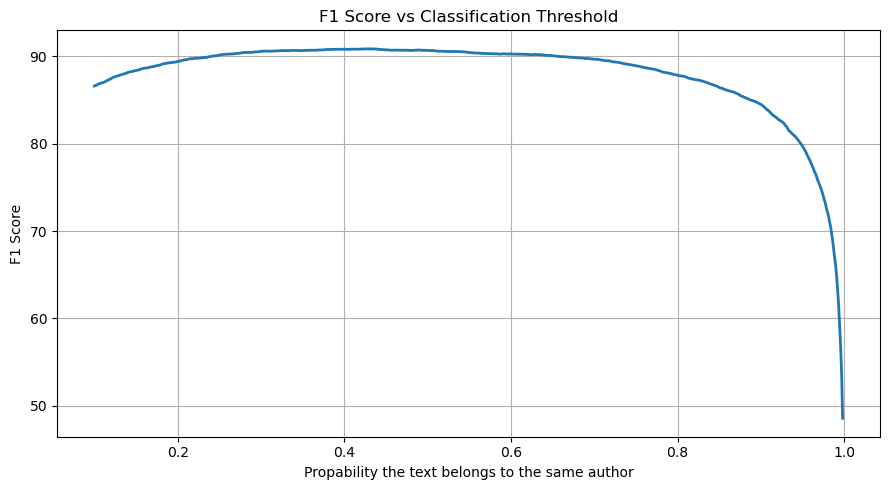

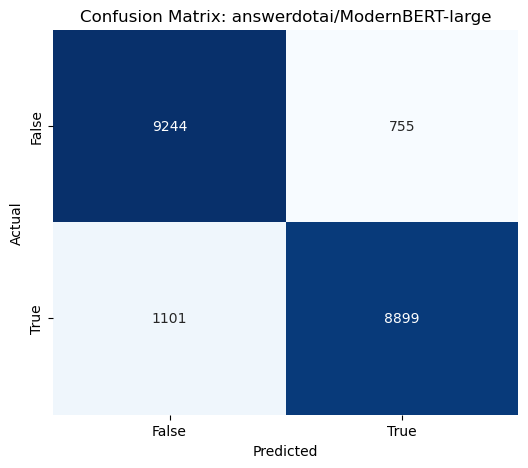

In [49]:
model = AutoModelForSequenceClassification.from_pretrained(
model_id,
num_labels=2,                # 0 = different author, 1 = same author
problem_type="single_label_classification" #not multiclass or regression
)
config.hidden_dropout = cl_dropout
config.attention_dropout = cl_dropout

model = model.to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=w_decay)

print(f"Starting full training  \n")
trained_model = train_classifier(
    model=model,
    df=final_train_df,
    optimizer=optimizer,
    epochs=epochs,
    batch_size=batch_s,
    warmup_ratio=wu_ratio,
    val_data_df=None
)

result_df = compute_classifier_scores(test_data_df, model)

#not gonna be used for assessment anymore - just for analysis
threshold_results_df = evaluate_classification_thresholds(result_df, classification_thresholds)
f1_threshold_histogram_fig = plot_f1_vs_threshold(threshold_results_df)

y_true = result_df["actual_result"]
y_pred = (result_df["propability_same_author"] >= top_propability_same_author).astype(int)

top_accuracy, top_precision, top_recall, top_f1 = evaluate_results(y_true, y_pred)

cm_fig = create_confusion_matrix(y_true, y_pred)

print(f"Top threshold: {top_propability_same_author}\n")
print(f"Top accuracy: { top_accuracy}\n")
print(f"Top precision: {top_precision}\n")
print(f"Top recall: {top_recall}\n")
print(f"Top f1: {top_f1}\n")

Save the model

In [50]:
model.to("cpu")
model.save_pretrained(finetuned_model_path)

Log the results

In [51]:
mlflow.set_experiment("/Users/jiripokorny455@gmail.com/JP_authorship_verification_dt")
with mlflow.start_run(run_name=f"{developer_initials}_{model_name}_results_{classification_type}"):
    mlflow.log_param("gpu_name", gpu_name)
    mlflow.log_param("gpu_vram_gb", gpu_vram_gb)
    
    mlflow.log_param("model_id ", model_id )
    mlflow.log_param("classification_type", classification_type)
    mlflow.log_table(data=trial_results_df, artifact_file="trial_results.json")
    
    mlflow.log_param("final_optimizer_learning_rate", lr)
    mlflow.log_param("final_epochs", epochs)
    mlflow.log_param("final_batch_size", batch_s)
    mlflow.log_param("final_weight_decay", w_decay)
    mlflow.log_param("final_warmup_ratio", wu_ratio)
    mlflow.log_param("final_classifier_dropout", cl_dropout)

    mlflow.log_table(data=result_df, artifact_file="embedding_similarity_results-test_data.json")

    mlflow.log_metric("top_threshold", top_propability_same_author)
    mlflow.log_metric("top_accuracy", top_accuracy)
    mlflow.log_metric("top_precision", top_precision)
    mlflow.log_metric("top_recall", top_recall)
    mlflow.log_metric("top_f1", top_f1)

    mlflow.log_figure(cm_fig, "confusion_matrix-test_data.png")

    mlflow.log_table(data=threshold_results_df, artifact_file="final_results_for_different_thresholds-test_data.json")
    mlflow.log_figure(f1_threshold_histogram_fig, "f1_results_threshold_histogram-test_data.png")


🏃 View run JP_ModernBERT-large_results_classification_head at: https://dbc-1ea3ad0e-f504.cloud.databricks.com/ml/experiments/134079680834040/runs/fcdcb54962d3495c91af62043e805d1d
🧪 View experiment at: https://dbc-1ea3ad0e-f504.cloud.databricks.com/ml/experiments/134079680834040
